In [1]:
import czifile
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters, measure, morphology
from scipy import ndimage
print("All imports successful!")

All imports successful!


In [8]:
# Read CZI File

# Specify file path (use /)
file_path = 'C:/Users/ezra.gonzalez/Desktop/GitHub/sample_image/Glutamate.czi'

# Read CZI
img = czifile.imread(file_path)

print(f"Array shape: {img.shape}")
print(f"Data type: {img.dtype}")
print(f"Min value: {img.min()}")
print(f"Max value: {img.max()}")

Array shape: (1, 1, 2, 1, 1, 1024, 1024, 1)
Data type: uint8
Min value: 0
Max value: 255


In [4]:
# Squeeze out singleton dimensions (scenes, time, z, rgb)
img_squeezed = np.squeeze(img)
print(f"Squeezed shape: {img_squeezed.shape}")

# Extract channels: 0 = blue (DAPI), 1 = green (SMI-31)
blue = img_squeezed[0]
green = img_squeezed[1]

print(f"Blue channel shape: {blue.shape}")
print(f"Green channel shape: {green.shape}")
print(f"Green min: {green.min()}, max: {green.max()}")

Squeezed shape: (2, 1024, 1024)
Blue channel shape: (1024, 1024)
Green channel shape: (1024, 1024)
Green min: 1, max: 255


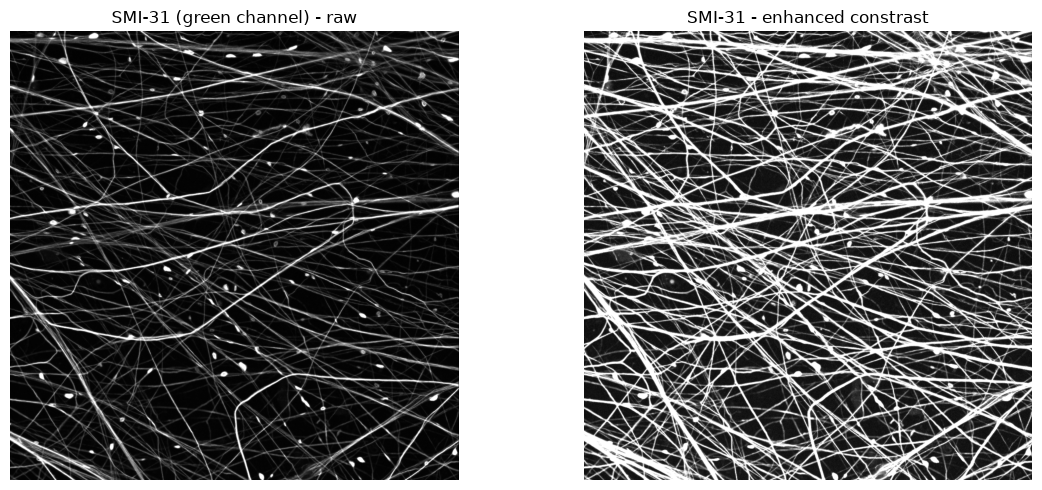

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # (1, 2): 1 row, 2 columns (two side by side plots)

axes[0].imshow(green, cmap='gray')
axes[0].set_title('SMI-31 (green channel) - raw')
axes[0].axis('off') # hides x/y tick marks and labels (clean look for images)

axes[1].imshow(green, cmap='gray', vmin=0, vmax=green.max()//4) #Adjusted contrast
axes[1].set_title('SMI-31 - enhanced constrast')
axes[1].axis('off')

plt.tight_layout()
plt.show()


DoG min: -92.88, max: 184.23


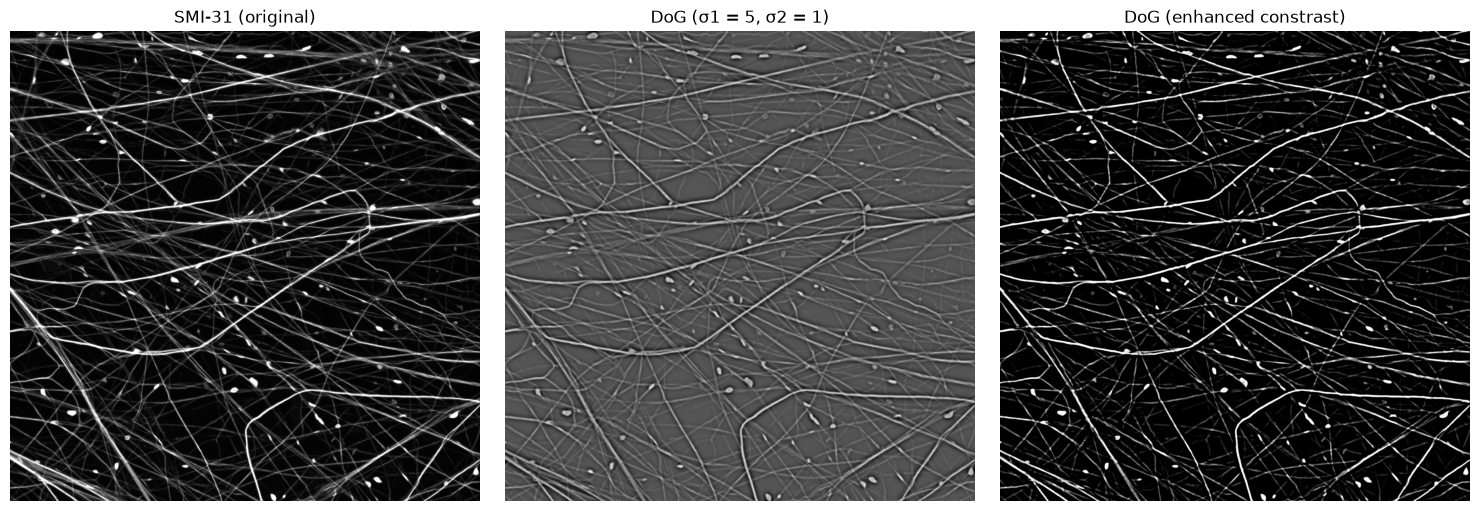

In [13]:
# Convert to float for filtering
green_float = green.astype(float)

# Two Gaussian blurs
sigma1, sigma2 = 5, 1
gauss1 = ndimage.gaussian_filter(green_float, sigma=sigma1)
gauss2 = ndimage.gaussian_filter(green_float, sigma=sigma2)

# Difference of Gaussians
dog = gauss2 - gauss1
print(f"DoG min: {dog.min():.2f}, max: {dog.max():.2f}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize = (15, 5))

axes[0].imshow(green, cmap='gray')
axes[0].set_title('SMI-31 (original)')
axes[0].axis('off')

axes[1].imshow(dog, cmap='gray')
axes[1].set_title(f'DoG (σ1 = {sigma1}, σ2 = {sigma2})')
axes[1].axis('off')

axes[2].imshow(dog, cmap = 'gray', vmin = 0, vmax=dog.max()*0.5)
axes[2].set_title('DoG (enhanced constrast)')
axes[2].axis('off')

plt.tight_layout()
plt.show()


Neurite area (pixels): 69147


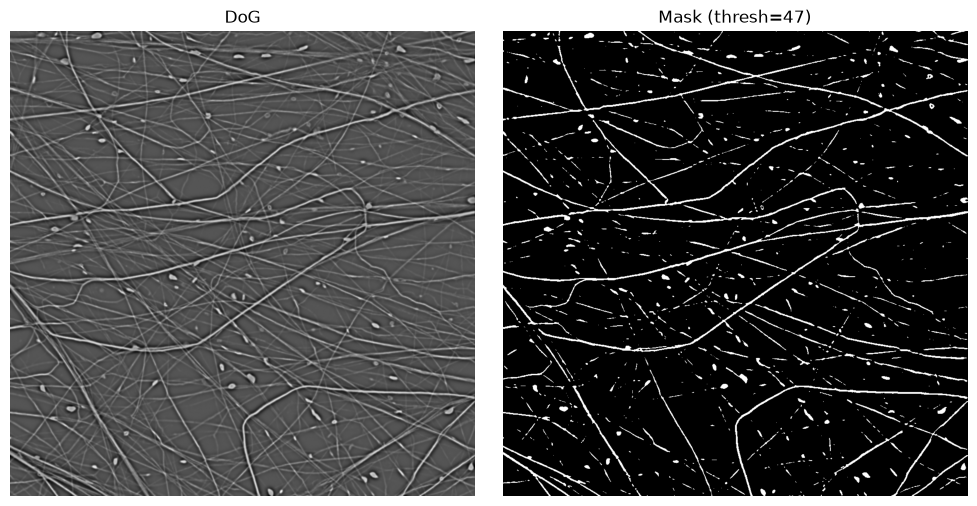

In [31]:
# TRESHOLDING

# Manual threshold - adjust until mask matches ImageJ
manual_thresh = 47
mask = dog > manual_thresh

# Measure area
area_pixels = np.sum(mask)
print(f"Neurite area (pixels): {area_pixels}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(dog, cmap='gray')
axes[0].set_title('DoG')
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title(f"Mask (thresh={manual_thresh})")
axes[1].axis('off')

plt.tight_layout()
plt.show()

Neurite area (pixels): 190525
Recalculated area: 18617.87 µm²


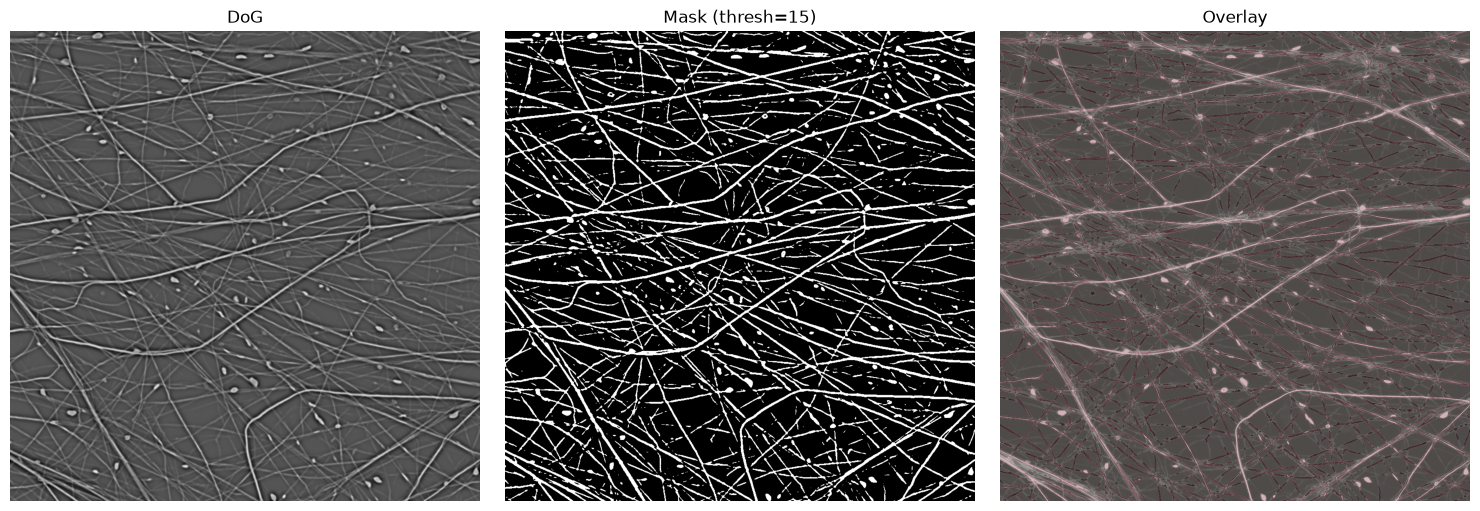

In [46]:
# TRESHOLDING

# Manual threshold - adjust until most neurites are included
neurite_thresh = 15
neurite_mask = dog > manual_thresh

# Measure area
area_pixels = np.sum(neurite_mask)
print(f"Neurite area (pixels): {area_pixels}")

scale_um_per_px = 0.3126
area_um2 = area_pixels * (scale_um_per_px ** 2)
print(f"Recalculated area: {area_um2:.2f} µm²")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(dog, cmap='gray')
axes[0].set_title('DoG')
axes[0].axis('off')

axes[1].imshow(neurite_mask, cmap='gray')
axes[1].set_title(f"Mask (thresh={neurite_thresh})")
axes[1].axis('off')

axes[2].imshow(green, cmap='gray')
axes[2].imshow(neurite_mask, cmap='Reds', alpha=0.3)  # Overlay mask on original
axes[2].set_title('Overlay')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Bead threshold: 250
Bead count: 81
Beads per 1000 µm²: 4.3507
Bead mask unique values: [False  True]
Bead mask sum (white pixels): 13426
Bead mask shape: (1024, 1024)
Total regions before filtering: 557
Regions after filtering: 81


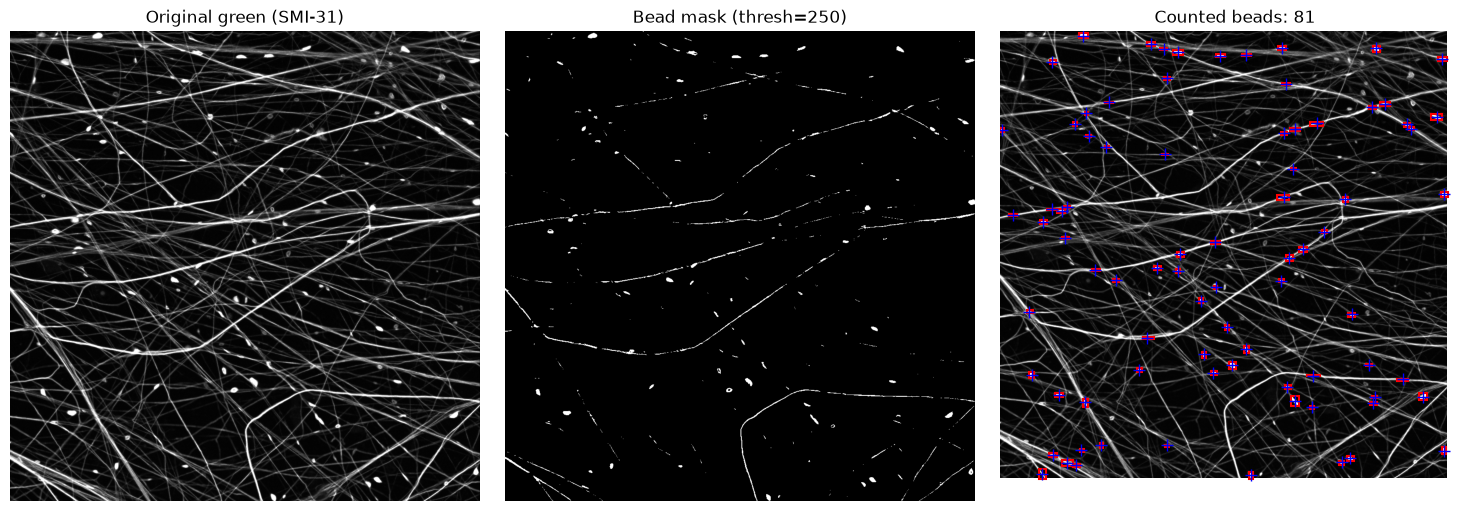

In [64]:
# Manual threshold - adjust until only beads are visible
bead_thresh = 250
bead_mask = green_8bit > bead_thresh

# label connected components
labeled = measure.label(bead_mask)

# Filter by size and circularity
regions = measure.regionprops(labeled)

bead_count = 0
for region in regions:
    # Size filter (4-80 pixels)
    if region.area < 25 or region.area > 200:
        continue
    # Circularity filter: 4π*area/perimeter²
    if region.perimeter > 0:
        circularity = 4 * np.pi * region.area / (region.perimeter **2)
    else:
        circularity = 0
    if circularity < 0.3 or circularity > 1.0:
        continue

    bead_count += 1

print(f"Bead threshold: {bead_thresh}")
print(f"Bead count: {bead_count}")

# Normalization
beads_per_1000um2 = 0
if area_um2 > 0:
    beads_per_1000um2 = (bead_count / area_um2) * 1000

print(f"Beads per 1000 µm²: {beads_per_1000um2:.4f}")


# Add this BEFORE the visualization to check what the mask contains
print(f"Bead mask unique values: {np.unique(bead_mask)}")
print(f"Bead mask sum (white pixels): {np.sum(bead_mask)}")
print(f"Bead mask shape: {bead_mask.shape}")

# Check if any beads passed filters
print(f"Total regions before filtering: {len(regions)}")
print(f"Regions after filtering: {bead_count}")


# Visualize beads
import matplotlib.patches as mpatches

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Original green
axes[0].imshow(green, cmap='gray')
axes[0].set_title('Original green (SMI-31)')
axes[0].axis('off')

# 2. Bead mask
axes[1].imshow(bead_mask, cmap='gray')
axes[1].set_title(f'Bead mask (thresh={bead_thresh})')
axes[1].axis('off')

# 3. Original with counted beads outlined
axes[2].imshow(green, cmap='gray')

# Re-run regionprops to get coordinates for plotting
regions_all = measure.regionprops(labeled)

for region in regions_all:
    # Apply same filters
    if region.area < 25 or region.area > 200:
        continue
    if region.perimeter > 0:
        circularity = 4 * np.pi * region.area / (region.perimeter ** 2)
    else:
        circularity = 0
    if circularity < 0.3 or circularity > 1.0:
        continue
    
    # Draw bounding box around counted bead
    minr, minc, maxr, maxc = region.bbox
    rect = mpatches.Rectangle((minc, minr), maxc - minc, maxr - minr,
                              fill=False, edgecolor='red', linewidth=1.5)
    axes[2].add_patch(rect)
    
    # Optional: mark centroid
    y, x = region.centroid
    axes[2].plot(x, y, 'b+', markersize=8)

axes[2].set_title(f'Counted beads: {bead_count}')
axes[2].axis('off')

plt.tight_layout()
plt.show()